# CNN Cat & Dog Classifier — Full Summary

##  Project Overview
This notebook builds a **Convolutional Neural Network (CNN)** using TensorFlow/Keras to perform **binary image classification** — distinguishing between **cats** and **dogs**.

It covers the complete deep learning pipeline:
1. **Data Preparation** — augmentation, normalization, train/validation split
2. **Model Architecture** — 2 Conv blocks + Dense layers
3. **Training** — 10 epochs with Adam optimizer
4. **Evaluation** — Accuracy & Loss curves
5. **Inference** — Predict on new images

---
###  Libraries Used
| Library | Purpose |
|---|---|
| `TensorFlow / Keras` | Deep learning framework |
| `NumPy` | Array operations |
| `Matplotlib` | Plotting accuracy & loss curves |


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.preprocessing.image import ImageDataGenerator

---
##  Step 1 — Data Preparation

The training images come from a local folder split into `cats/` and `dogs/` subfolders.

### Augmentation applied (via `ImageDataGenerator`):
| Technique | Value |
|---|---|
| Rescaling (normalization) | `1/255` — scales pixels to [0, 1] |
| Shear Range | 0.2 |
| Zoom Range | 0.2 |
| Horizontal Flip | ✅ Enabled |
| Train/Validation Split | 80% train / 20% validation |

> **Dataset loaded:** `6,404 training images` + `1,601 validation images` (2 classes: cats, dogs)


In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    '/Users/ashiksherif/Downloads/training_set',
    target_size=(64,64),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    '/Users/ashiksherif/Downloads/training_set',
    target_size=(64,64),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 6404 images belonging to 2 classes.
Found 1601 images belonging to 2 classes.


---
## Step 2 — Model Architecture

A **Sequential CNN** is built layer by layer:

```
Input: (64, 64, 3) — RGB image
│
├── Conv2D (32 filters, 3×3, ReLU)      ← Detects low-level features
├── MaxPooling2D (2×2, stride 2)         ← Reduces spatial size
│
├── Conv2D (32 filters, 3×3, ReLU)      ← Detects higher-level features
├── MaxPooling2D (2×2, stride 2)         ← Further reduces spatial size
│
├── Flatten                              ← Converts 2D maps to 1D vector
├── Dense (128 units, ReLU)             ← Learns feature combinations
├── Dropout (0.5)                        ← Prevents overfitting
│
└── Dense (1 unit, Sigmoid)             ← Output: probability (Cat=0, Dog=1)
```

> **Threshold:** `result > 0.5` → Dog | `result ≤ 0.5` → Cat


In [3]:
cnn = Sequential()

In [4]:
cnn.add(
    Conv2D(
        filters=32,
        kernel_size=3,
        activation='relu',
        input_shape=(64,64,3)
    )
)

/opt/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
cnn.add(MaxPooling2D(pool_size=2, strides=2))

In [6]:
cnn.add(
    Conv2D(
        filters=32,
        kernel_size=3,
        activation='relu'
    )
)

In [7]:
cnn.add(MaxPooling2D(pool_size=2, strides=2))

In [8]:
cnn.add(Flatten())

In [9]:
cnn.add(Dense(units=128, activation='relu'))

In [10]:
cnn.add(Dropout(0.5))

In [11]:
cnn.add(Dense(units=1, activation='sigmoid'))

---
##  Step 3 — Model Compilation

| Setting | Value |
|---|---|
| **Optimizer** | Adam (adaptive learning rate) |
| **Loss Function** | Binary Cross-Entropy (standard for 2-class problems) |
| **Metric** | Accuracy |


In [12]:
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

---
##  Step 4 — Training Results (10 Epochs)

| Epoch | Train Acc | Val Acc | Train Loss | Val Loss |
|-------|-----------|---------|------------|----------|
| 1     | 56.2%     | 61.4%   | 0.6864     | 0.6559   |
| 2     | 61.9%     | 64.5%   | 0.6565     | 0.6302   |
| 3     | 66.7%     | 68.6%   | 0.6202     | 0.6005   |
| 4     | 69.9%     | 71.3%   | 0.5798     | 0.5560   |
| 5     | 72.2%     | 69.8%   | 0.5533     | 0.5613   |
| 6     | 73.1%     | 72.5%   | 0.5368     | 0.5380   |
| 7     | 75.1%     | 75.3%   | 0.5145     | 0.5032   |
| 8     | 75.3%     | 74.9%   | 0.5019     | 0.4965   |
| 9     | 76.7%     | 76.8%   | 0.4780     | 0.4745   |
| 10    | 77.9%     | 76.3%   | 0.4704     | 0.4849   |

###  Key Observations:
-  Both accuracy and loss are improving steadily — model is **learning well**
-  Validation accuracy closely tracks training accuracy — **no significant overfitting**
-  Epoch 5 shows a slight dip in validation accuracy — typical stochastic behavior
-  Final val accuracy: **~76%** — solid result for a simple CNN from scratch on 64×64 images


In [13]:
history = cnn.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.5623 - loss: 0.6864 - val_accuracy: 0.6140 - val_loss: 0.6559
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.6195 - loss: 0.6565 - val_accuracy: 0.6446 - val_loss: 0.6302
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.6669 - loss: 0.6202 - val_accuracy: 0.6858 - val_loss: 0.6005
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.6996 - loss: 0.5798 - val_accuracy: 0.7133 - val_loss: 0.5560
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7219 - loss: 0.5533 - val_accuracy: 0.6983 - val_loss: 0.5613
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7309 - loss: 0.5368 - val_accuracy: 0.7252 - val_loss: 0.5380
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.7506 - loss: 0.5145 - val_accuracy: 0.7527 - val_loss: 0.5032
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7528 - loss: 0.5019 - val_accu

---
##  Step 5 — Accuracy & Loss Visualization

The plots below show:
- **Model Accuracy:** Training vs. Validation accuracy per epoch
- **Model Loss:** Training vs. Validation loss per epoch

> Ideal result: both curves converge and stabilize — indicating a **well-fitted model**.


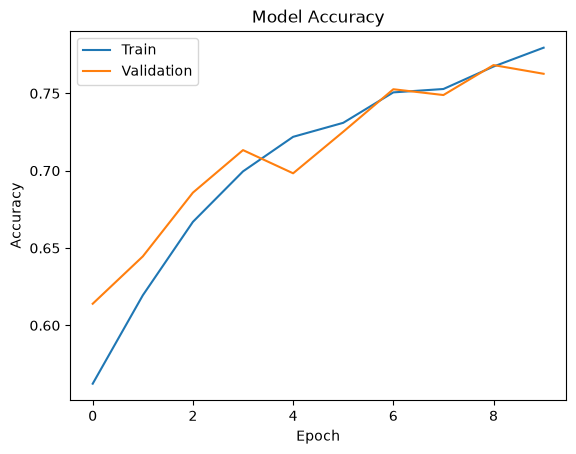

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.show()

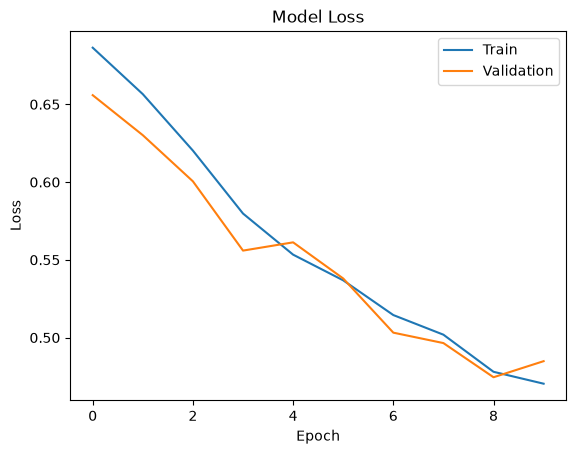

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.show()

---
##  Step 6 — Save Model

The trained model is saved in HDF5 (`.h5`) format for future use without retraining.

> **Note:** Keras recommends the newer `.keras` format instead of `.h5` going forward.


In [16]:
cnn.save("cats_dogs_cnn.h5")

---
##  Step 7 — Single Image Inference

New images are tested by:
1. Loading and resizing to 64×64
2. Converting to NumPy array
3. Adding batch dimension (`expand_dims`)
4. Normalizing pixels to [0, 1]
5. Running `cnn.predict()` and applying threshold

###  Test Results:
| Image | Prediction | Correct? |
|-------|-----------|----------|
| `cat images.jpeg` | **Cat** | ✅ Yes |
| `Dog image .jpg` | **Dog** | ✅ Yes |


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Cat


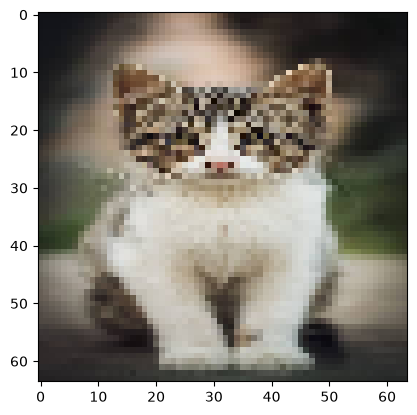

In [22]:
from tensorflow.keras.preprocessing import image

test_image = image.load_img(
    '/Users/ashiksherif/Downloads/cat images.jpeg',
    target_size=(64,64)
)
plt. imshow(test_image)
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis=0)
test_image = test_image / 255.0

result = cnn.predict(test_image)

if result[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Dog


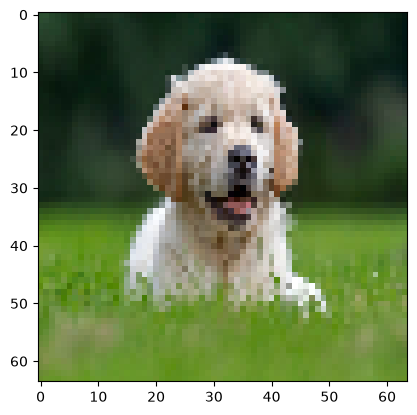

In [21]:
from tensorflow.keras.preprocessing import image

test_image = image.load_img(
    '/Users/ashiksherif/Downloads/Dog image .jpg',
    target_size=(64,64)
)
plt. imshow(test_image)

test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis=0)
test_image = test_image / 255.0

result = cnn.predict(test_image)

if result[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

---
##  Step 8 — Key Insights & Recommendations

###  Strengths
- Clean, modular cell structure — easy to follow
- **Dropout (0.5)** effectively reduces overfitting
- **Data augmentation** improves generalization
- Validation split built into `ImageDataGenerator` (no separate folder needed)
- Both test predictions are **correct**

###  Areas to Improve
| Issue | Recommendation |
|-------|---------------|
| Small image size (64×64) | Try 128×128 or 224×224 for better feature capture |
| Only 10 epochs | Add **Early Stopping** + more epochs |
| No scheduler | Add `ReduceLROnPlateau` for better convergence |
| Hardcoded local paths | Use relative paths or environment variables |
| No test set | Create a separate holdout test set for honest evaluation |
| `.h5` format deprecated | Use `.keras` format instead |
| Custom CNN (~76% acc) | Try **Transfer Learning** (MobileNetV2, VGG16) for >95% accuracy |

###  Overall Assessment
This is a well-structured beginner CNN project. The model achieves ~76% validation accuracy on a binary image classification task, which is a solid baseline. With transfer learning and larger input images, this could easily reach 95%+.

---
*Summary added to: `CNN_Cat_and_Dog.ipynb`*
